In [ ]:
!pip install -qU ultralytics wandb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.2/20.2 MB 115.4 MB/s eta 0:00:00


In [ ]:
import os
import glob
import json
import random
import string
import shutil
from tqdm import tqdm

from pathlib import Path
from typing import Generator, Tuple, Optional, List, Tuple, Any

import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from google.colab import userdata

import wandb


ROOT_DIR = Path("../").resolve()
DATA_DIR = ROOT_DIR / "data"
WANDB_API_KEY = userdata.get('WANDB_API_KEY')

os.environ["WANDB_API_KEY"] = WANDB_API_KEY
wandb.login(key=WANDB_API_KEY)

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: octoopt to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [ ]:
!yolo settings wandb=True

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Updated 'wandb=True'
JSONDict("/root/.config/Ultralytics/settings.json"):
{
  "settings_version": "0.0.6",
  "datasets_dir": "/content/datasets",
  "weights_dir": "weights",
  "runs_dir": "runs",
  "uuid": "569f3ba64b326db489132663f79cd37279811de477381b83ac131e6cdd129cbb",
  "sync": true,
  "api_key": "",
  "openai_api_key": "",
  "clearml": true,
  "comet": true,
  "dvc": true,
  "hub": true,
  "mlflow": true,
  "neptune": true,
  "raytune": true,
  "tensorboard": false,
  "wandb": true,
  "vscode_msg": true,
  "openvino_msg": true
}
💡 Learn more about Ultralytics Settings at https://docs.ultralytics.com/quickstart/#ultralytics-settings


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -v ./drive/MyDrive/Dataset/ZAIC_2025/yolo_dataset.zip .
!unzip yolo_dataset.zip -d .

Streaming output truncated to the last 5000 lines.
  inflating: ./yolo_dataset/labels/Backpack_0_frame9372.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9387.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9421.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9433.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9441.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9467.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9473.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9510.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9515.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9535.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9564.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9588.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9603.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9628.txt  
  inflating: ./yolo_dataset/labels/Backpack_0_frame9634.txt  
  inflating: ./yolo

In [ ]:
def split_yolo_dataset(root="yolo_dataset", out="dataset",
                       train_ratio=0.7, val_ratio=0.1, test_ratio=0.2,
                       seed=None):

    if seed is not None:
        random.seed(seed)

    root = Path(root)
    out = Path(out)

    images = list((root / "images").glob("*.jpg"))
    random.shuffle(images)

    total = len(images)
    train_count = int(total * train_ratio)
    val_count   = int(total * val_ratio)

    train_imgs = images[:train_count]
    val_imgs   = images[train_count:train_count + val_count]
    test_imgs  = images[train_count + val_count:]

    # -----------------------------
    # Create output dirs
    # -----------------------------
    for split in ["train", "val", "test"]:
        (out / split / "images").mkdir(parents=True, exist_ok=True)
        (out / split / "labels").mkdir(parents=True, exist_ok=True)

    # -----------------------------
    # Move function with tqdm
    # -----------------------------
    def move_files(img_list, split):
        print(f"\nMoving {split} files...")
        for img in tqdm(img_list, desc=f"{split}", ncols=70):
            lbl = root / "labels" / img.name.replace(".jpg", ".txt")

            shutil.copy(img, out / split / "images" / img.name)
            shutil.copy(lbl, out / split / "labels" / lbl.name)

    move_files(train_imgs, "train")
    move_files(val_imgs, "val")
    move_files(test_imgs, "test")

    print("\n✔ Dataset split completed!")
    print(f"Train: {len(train_imgs)} images")
    print(f"Val:   {len(val_imgs)} images")
    print(f"Test:  {len(test_imgs)} images")


def visualize_random_yolo(dataset_root="dataset/train", num_images=5):
    img_dir = Path(dataset_root) / "images"
    lbl_dir = Path(dataset_root) / "labels"

    images = list(img_dir.glob("*.jpg"))
    random.shuffle(images)
    images = images[:num_images]

    for img_path in images:
        label_path = lbl_dir / img_path.name.replace(".jpg", ".txt")

        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        h, w = img.shape[:2]

        # draw boxes
        if label_path.exists():
            with open(label_path, "r") as f:
                for line in f:
                    cls_id, cx, cy, bw, bh = map(float, line.split())

                    x1 = int((cx - bw/2) * w)
                    y1 = int((cy - bh/2) * h)
                    x2 = int((cx + bw/2) * w)
                    y2 = int((cy + bh/2) * h)

                    cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
                    cv2.putText(img, str(int(cls_id)), (x1, y1-5),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255,0,0), 2)

        plt.figure(figsize=(8,8))
        plt.imshow(img)
        plt.title(img_path.name)
        plt.axis("off")
        plt.show()

def random_exp_name(prefix="yolo"):
    rand = "".join(random.choices(string.ascii_lowercase + string.digits, k=6))
    return f"{prefix}_{rand}"

In [ ]:
split_yolo_dataset(
    root='/content/yolo_dataset'
)


Moving train files...


train: 100%|██████████████████| 14074/14074 [00:10<00:00, 1332.71it/s]



Moving val files...


val: 100%|██████████████████████| 2010/2010 [00:00<00:00, 2575.10it/s]



Moving test files...


test: 100%|█████████████████████| 4022/4022 [00:02<00:00, 1851.85it/s]


✔ Dataset split completed!
Train: 14074 images
Val:   2010 images
Test:  4022 images


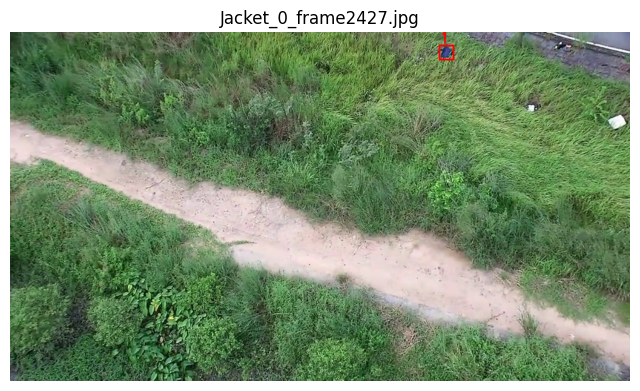

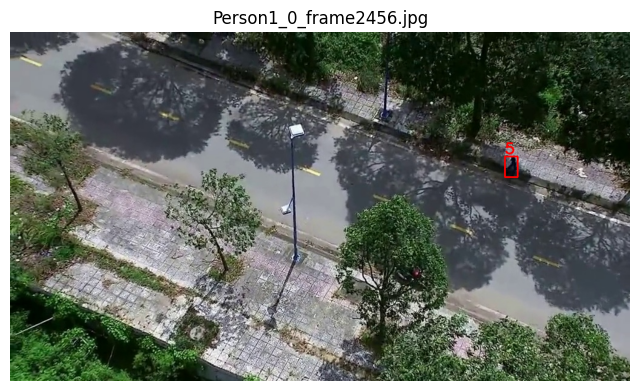

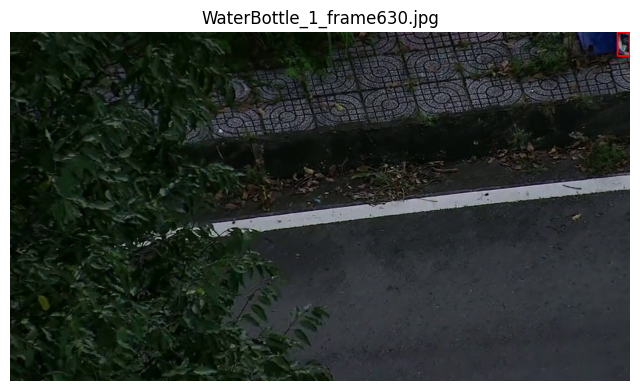

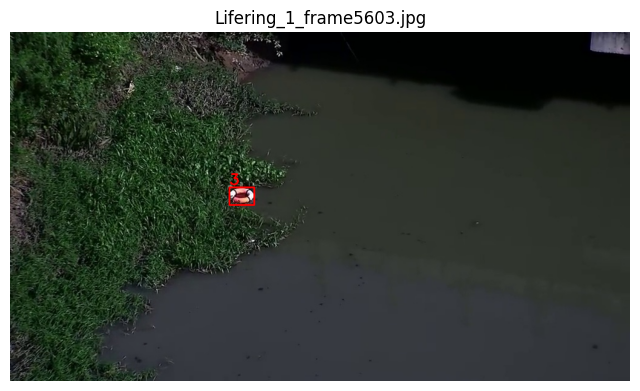

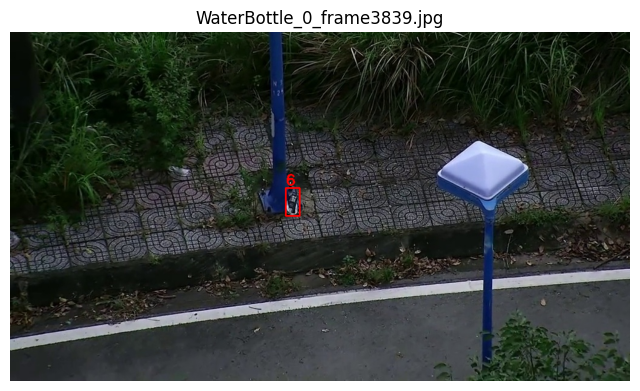

In [ ]:
visualize_random_yolo()

In [ ]:
yaml_text = """
path: dataset
train: train/images
val: val/images
test: test/images

names:
  0: Backpack
  1: Jacket
  2: Laptop
  3: Person
  4: WaterBottle
  5: Lifering
  6: MobilePhone
"""

with open("dataset.yaml", "w") as f:
    f.write(yaml_text)

print(open("dataset.yaml").read())



path: dataset
train: train/images
val: val/images
test: test/images

names:
  0: Backpack
  1: Jacket
  2: Laptop
  3: Person
  4: WaterBottle
  5: Lifering
  6: MobilePhone



In [ ]:
from ultralytics import YOLO

model = YOLO("yolo11n.pt")
model

YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C3k2(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(64, eps=0.001, momentum=0.03, affine=True, track_running_

In [ ]:
exp_name = random_exp_name(prefix="zaic_yolo11n")
project="ZAIC2025_AeroEyes"

model.train(
    # -----------------------------
    #  Dataset (Optimized for Small Objects)
    # -----------------------------
    data="dataset.yaml",
    epochs=50,
    imgsz=1280,            # 🔑 KEY CHANGE: Higher resolution for more pixels on drones
    batch=32,
    workers=8,

    # -----------------------------
    #  Optimization
    # -----------------------------
    lr0=0.02,
    lrf=0.01,
    momentum=0.94,
    weight_decay=0.0005,
    optimizer="AdamW",

    warmup_epochs=5.0,     # 🔑 KEY CHANGE: Longer warmup for stability
    warmup_momentum=0.85,
    warmup_bias_lr=0.1,

    # -----------------------------
    #  Loss & Training Behaviour (Optimized for Small Objects)
    # -----------------------------
    close_mosaic=10,
    patience=30,
    conf=0.01,             # Slightly increased
    iou=0.5,               # 🔑 KEY CHANGE: Higher IoU threshold for precise localization

    # -----------------------------
    #  Data Augmentation (Optimized for Small Objects)
    # -----------------------------
    hsv_h=0.02,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=5.0,
    translate=0.1,
    scale=0.9,             # 🔑 KEY CHANGE: Keeps object sizes closer to original
    shear=2.0,
    perspective=0.0005,
    flipud=0.0,
    fliplr=0.5,
    mosaic=0.5,            # 🔑 KEY CHANGE: Reduced probability to preserve context
    mixup=0.1,
    copy_paste=0.3,          # 🔑 KEY CHANGE: Increased to generate more drone examples

    # -----------------------------
    # 🖥 Mixed Precision + Device
    # -----------------------------
    device=0,
    amp=True,

    # -----------------------------
    #  Saving & Checkpoints
    # -----------------------------
    project=project,
    name=exp_name,
    save=True,
    save_period=5,

    # -----------------------------
    #  Validation & Logging
    # -----------------------------
    val=True,
    verbose=True,
    plots=True,

    # -----------------------------
    #  Regularization & Freezing (Optimized for Small Objects)
    # -----------------------------
    dropout=0.1,           # Reduced slightly to rely more on available features
    freeze=0,

    # -----------------------------
    #  Experimental Features
    # -----------------------------
    overlap_mask=True,
    mask_ratio=4,
)

Ultralytics 8.3.228 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (NVIDIA L4, 22693MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=0.01, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=5.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=0, half=False, hsv_h=0.02, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.5, keras=False, kobj=1.0, line_width=None, lr0=0.02, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.1, mode=train, model=yolo11n.pt, momentum=0.94, mosaic=0.5, multi_scale=False, name=zaic_yolo11n_rfc58r, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=30, perspective=0.0005, plots=True, pose=12.0, 

Overriding model.yaml nc=80 with nc=7

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      6640  ultralytics.nn.modules.block.C3k2            [32, 64, 1, False, 0.25]      
  3                  -1  1     36992  ultralytics.nn.modules.conv.Conv             [64, 64, 3, 2]                
  4                  -1  1     26080  ultralytics.nn.modules.block.C3k2            [64, 128, 1, False, 0.25]     
  5                  -1  1    147712  ultralytics.nn.modules.conv.Conv             [128, 128, 3, 2]              
  6                  -1  1     87040  ultralytics.nn.modules.block.C3k2            [128, 128, 1, True]           
  7                  -1  1    295424  ultralytics

lr/pg0,█▇▄▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
lr/pg1,▂▄▅███▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▄▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
lr/pg2,▂▄▅▇██▇▇▇▇▇▆▆▆▆▆▆▅▅▅▅▅▄▄▄▄▃▃▃▃▃▃▂▂▂▂▂▁▁▁
metrics/mAP50(B),▂▁▇▇▇▇▇█▇███████████████████████████████
metrics/mAP50-95(B),▂▁▅▄▆▆▆▆▆▇▇▇▇▇▇▇▇█▇▇█▇█▇█▇█▇▇███████████
metrics/precision(B),▅▁▆▇▆███████████████████████████████████
metrics/recall(B),▁▂▇▇▇██▇████████████████████████████████
model/GFLOPs,▁
model/parameters,▁
model/speed_PyTorch(ms),▁
+6,...


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7ec28d745400>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
  

In [ ]:
# model.val(data='dataset.yaml')

In [ ]:
# Should be as onnix
model.export(format="onnx")